In [1]:
%%capture
!pip install scrapling browserforge playwright

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abedkhooli/arabic-100k-reviews")

print("Path to dataset files:", path)

100%|██████████| 17.0M/17.0M [00:00<00:00, 77.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/abedkhooli/arabic-100k-reviews/versions/4


In [2]:
%%capture
from tqdm import tqdm
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import string
import os
# from scrapling import Fetcher
# from scrapling.fetchers import FetcherSession
import nltk
nltk.download("punkt")
nltk.download('punkt_tab')
nltk.download("stopwords")
nltk.download("wordnet")
from nltk import word_tokenize, WordNetLemmatizer
from nltk.corpus import stopwords
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score ,ConfusionMatrixDisplay,f1_score,precision_score,recall_score
from imblearn.over_sampling import SMOTE
from nltk.stem.isri import ISRIStemmer
import tensorflow as tf
import keras
import joblib

In [ ]:
# def get_url(page_urls, end):
#     links = []
#     for base_url in tqdm(page_urls):
#         for page_num in range(1, end + 1):
#             page = Fetcher.get(f"{base_url}{page_num}", allow_redirects=True)
#             check_result = page.css(".styles_noResults__PBJpZ h2::text").get()
#             if check_result == "No results":
#                 break
#             card_elements = page.css(".CDS_Card_card__146e7a.styles_card__WMwue")
#             for card_element in card_elements:
#                 review_count_str = card_element.css(".styles_reviewCount__iwsDS.styles_underline__3kG9x span::text").get() or '0'
#                 if int(review_count_str) > 5:
#                   url = card_element.css("a::attr(href)").get()
#                   if url:
#                     full_url = f"https://www.trustpilot.com{url}"
#                     links.append(full_url)
#                   # print(f"URL: {full_url}, Review Count: {review_count_str}")

#     return links

In [ ]:
# categories = ["https://www.trustpilot.com/categories/animals_pets?claimed=true&country=EG&page=",
#      "https://www.trustpilot.com/categories/events_entertainment?claimed=true&country=EG&page=",
#      "https://www.trustpilot.com/categories/home_garden?claimed=true&country=EG&page=",
#      "https://www.trustpilot.com/categories/beauty_wellbeing?claimed=true&country=EG&page=",
#      "https://www.trustpilot.com/categories/food_beverages_tobacco?claimed=true&country=EG&page=",
#      "https://www.trustpilot.com/categories/home_services?claimed=true&country=EG&page=",
#      "https://www.trustpilot.com/categories/shopping_fashion?claimed=true&country=EG&page=",
#      "https://www.trustpilot.com/categories/business_services?claimed=true&country=EG&page=",
#      "https://www.trustpilot.com/categories/health_medical?claimed=true&country=EG&page=",
#      "https://www.trustpilot.com/categories/legal_services_government?claimed=true&country=EG&page=",
#      "https://www.trustpilot.com/categories/sports?claimed=true&country=EG&page=",
#      "https://www.trustpilot.com/categories/education_training?claimed=true&country=EG&page=",
#      "https://www.trustpilot.com/categories/hobbies_crafts?claimed=true&country=EG&page=",
#      "https://www.trustpilot.com/categories/money_insurance?claimed=true&country=EG&page=",
#      "https://www.trustpilot.com/categories/travel_vacation?claimed=true&country=EG&page=",
#      "https://www.trustpilot.com/categories/public_local_services?claimed=true&country=EG&page=",
#      "https://www.trustpilot.com/categories/vehicles_transportation?claimed=true&country=EG&page=",
#      "https://www.trustpilot.com/categories/electronics_technology?claimed=true&country=EG&page="]
# urls = get_url(categories,15)

In [ ]:
# def get_reviews(urls):
#   data = []
#   for base_url in tqdm(urls):
#     company_page = Fetcher.get(base_url, allow_redirects=True)
#     company_name = company_page.css(".title_displayName__9lGaz::text").get()
#     company_category = company_page.css(".styles_breadcrumbLink__izGHa::text").get()
#     for page_num in range(1,11):
#       paged_url = f"{base_url}?page={page_num}"
#       page = Fetcher.get(paged_url,allow_redirects=True)
#       check_404 = page.css(".CDS_Typography_display-s__da5bc0::text").get()
#       if check_404 == "Whoops!":
#         break
#       container_review = page.css(".styles_reviewCard__Qwhpy")
#       for review_div in container_review:
#         name = review_div.css(".styles_consumerName__xKr9c::text").get()
#         date = review_div.css(".CDS_Badge_badgeText__09cbb6::text").get()
#         location = review_div.css(".CDS_Typography_body-m__da5bc0::text").get()
#         rating = review_div.css(".styles_reviewHeader__DzoAZ::attr(data-service-review-rating)").get()
#         review = review_div.css(".CDS_Typography_body-l__da5bc0::text").get()
#         scraping_date = datetime.now().strftime("%Y-%m-%d")
#         if review is None:
#           review = review_div.css("h2.CDS_Typography_heading-xs__da5bc0::text").get()
#         review_url = f"https://www.trustpilot.com{review_div.css(".CDS_Link_noUnderline__a59334::attr(href)").get()}"
#         data.append({"company_name": company_name, "company_category": company_category, "name": name, "date": date, "location": location, "rating": rating, "review": review, "review_url": review_url,"scraping_date":scraping_date})
#   data = pd.DataFrame(data)
#   data.to_csv("reviews.csv",index=False)
#   return data

In [ ]:
# data = get_reviews(urls)

In [27]:
data = pd.read_csv("/content/reviews.csv")

In [16]:
def print_details(data):
  print('Dataset size:',data.shape)
  print('Columns are:',data.columns)
  print(data.head())
  print(data.info())

In [17]:
print_details(data)

Dataset size: (11162, 9)
Columns are: Index(['company_name', 'company_category', 'name', 'date', 'location',
       'rating', 'review', 'review_url', 'scraping_date'],
      dtype='object')
  company_name company_category                    name              date  \
0      Petman         Pet Store           Mina Mekhaeel      May 24, 2024   
1      Petman         Pet Store           camilla zalka  January 15, 2023   
2      Petman         Pet Store              Ahmed Kady    April 29, 2022   
3      Petman         Pet Store       Miss Sherine Zaki    April 22, 2022   
4      Petman         Pet Store  Magued ماجد Kamal كمال  January 21, 2022   

  location  rating                                             review  \
0       EG       5  Nice packages the food smells okay and Charlie...   
1       EG       5  Easy to order, quick to deliver, great custome...   
2       EG       5  Great quality dream and prompt service.. highl...   
3       EG       3  Dogs tried all three, one of them t

In [28]:
data.dropna(inplace=True)

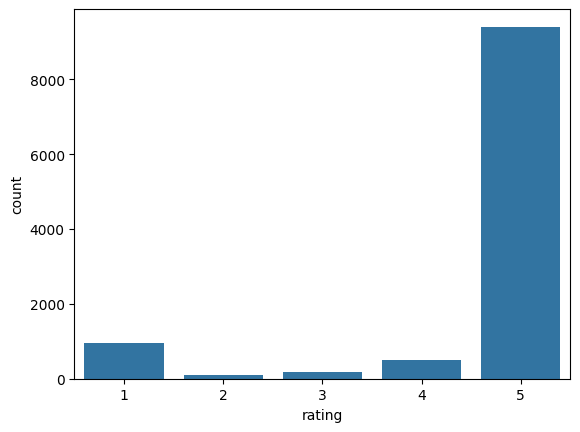

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=data, x="rating")
plt.show()

In [20]:
data["rating"].value_counts()

,count
rating,
5,9405
1,956
4,500
3,186
2,111


In [29]:
data = data[['rating','review']]

In [10]:
data.head()

,rating,review
0,5,Nice packages the food smells okay and Charlie...
1,5,"Easy to order, quick to deliver, great custome..."
2,5,Great quality dream and prompt service.. highl...
3,3,"Dogs tried all three, one of them that had len..."
4,5,Excellant service with perfect dog food.\nLove...


In [31]:
some_arabic_reviews = pd.read_csv("/root/.cache/kagglehub/datasets/abedkhooli/arabic-100k-reviews/versions/4/ar_reviews_100k.tsv",sep="\t")
some_arabic_reviews = some_arabic_reviews[some_arabic_reviews['label'] != 'Mixed']
some_arabic_reviews.rename(columns={"text":"review","label":"rating"},inplace=True)
some_arabic_reviews['rating'].replace({"Negative": 1, "Positive": 5}, inplace=True)

/tmp/ipykernel_764/3219586397.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  some_arabic_reviews['rating'].replace({"Negative": 1, "Positive": 5}, inplace=True)
/tmp/ipykernel_764/3219586397.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  some_arabic_reviews['rating'].replace({"Negative": 1

In [32]:
some_arabic_reviews = some_arabic_reviews.sample(frac=.18)

In [33]:
data = pd.concat([data,some_arabic_reviews])

In [35]:
data.shape

(23158, 2)

In [16]:
# from wordcloud import WordCloud
def generate_word_cloud(text):
    wordcloud = WordCloud(
        width = 4000,
        height = 3000,
        background_color = 'black').generate(str(text))
    fig = plt.figure(
        figsize = (20, 10),
        facecolor = 'k',
        edgecolor = 'k')
    plt.imshow(wordcloud, interpolation = 'bilinear')
    plt.axis('off')
    plt.tight_layout(pad=0)
    plt.show()

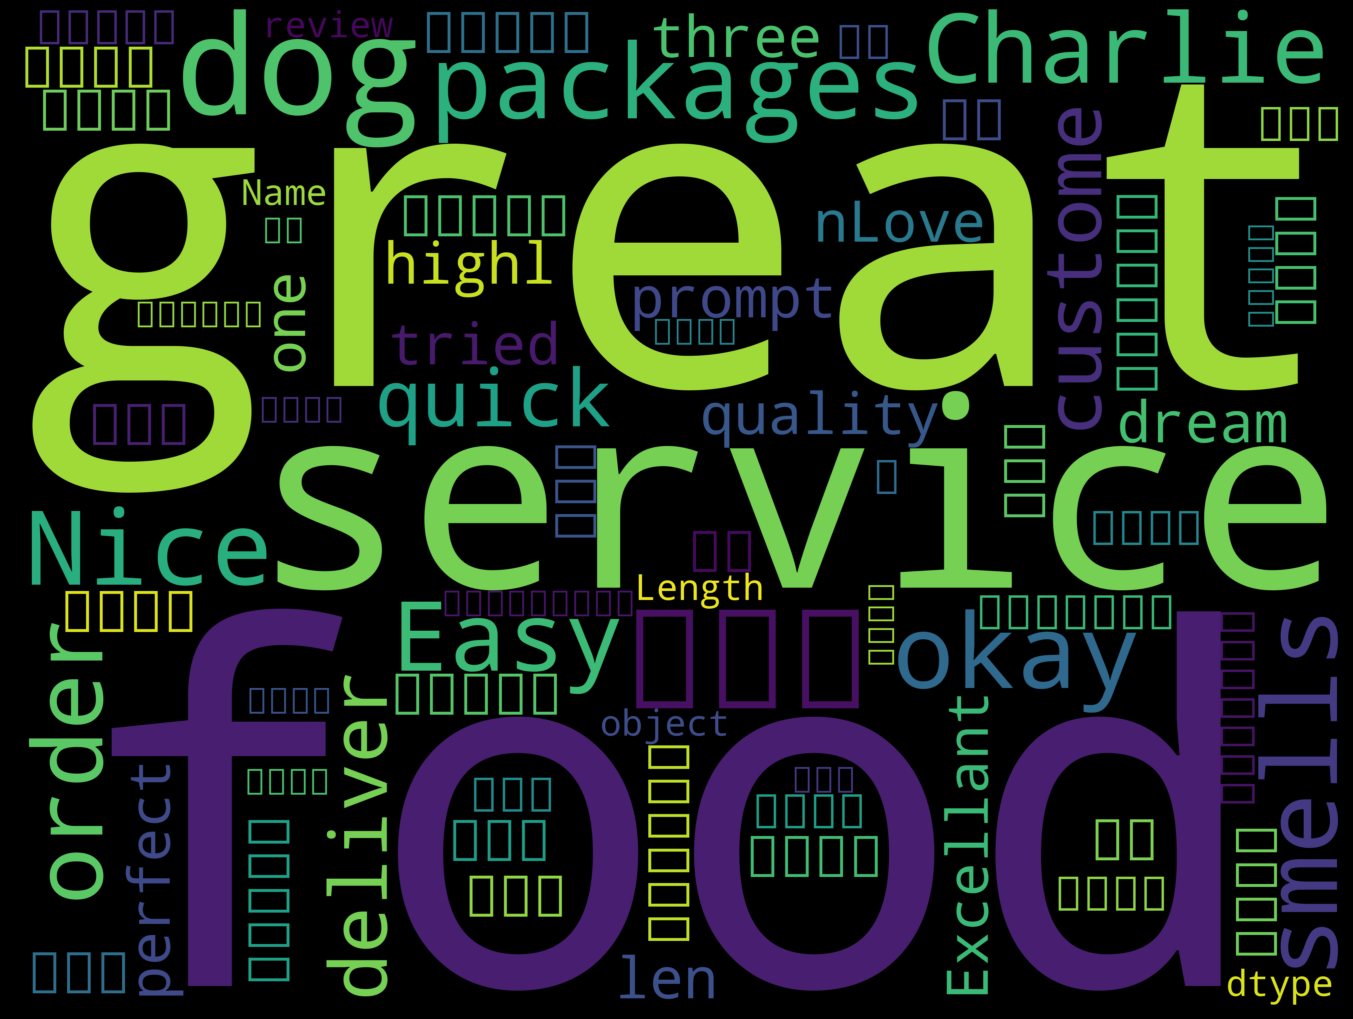

In [19]:
generate_word_cloud(data['review'])

In [36]:
data["Numbers"] = data["review"].str.count(r"\d")
data["Special"] = data["review"].str.count(r"[!@#$%^&*()]")

In [37]:
def split_review(text):
    arabic_pattern = re.compile(r"[\u0600-\u06FF]+")
    english_pattern = re.compile(r"[A-Za-z]+")
    if not isinstance(text, str):
        return pd.Series([np.nan, np.nan])

    arabic_words = arabic_pattern.findall(text)
    english_words = english_pattern.findall(text)

    return pd.Series([
        " ".join(english_words) or np.nan,
        " ".join(arabic_words) or np.nan
    ])

In [38]:
def process_review_text_en(text):

    if not isinstance(text, str):
        return pd.Series([np.nan, 0, 0])

    RLength = len(text)
    SentenceLength = len(text.split())

    stop_words = set(stopwords.words("english"))
    punctuations = set(string.punctuation)
    lemmatizer = WordNetLemmatizer()
    tokens = word_tokenize(text.lower())

    processed_tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and t not in punctuations]
    cleaned_text = " ".join(processed_tokens)

    return pd.Series([cleaned_text, RLength, SentenceLength])

In [39]:
def process_review_text_ar(text):

    if not isinstance(text, str):
        return pd.Series([np.nan, 0, 0])

    RLength = len(text)
    SentenceLength = len(text.split())

    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub(r"ى", "ي", text)
    text = re.sub(r"ؤ", "و", text)
    text = re.sub(r"ئ", "ي", text)
    text = re.sub(r"ة", "ه", text)
    # Remove (تشكيل)
    text = re.sub(r"[\u0617-\u061A\u064B-\u0652]", "", text)

    stop_words = set(stopwords.words("arabic"))
    punctuations = set(string.punctuation)
    stemmer_ar = ISRIStemmer()
    tokens = word_tokenize(text.lower())
    processed_tokens = [stemmer_ar.stem(t)for t in tokens if t not in stop_words and t not in punctuations]
    cleaned_text = " ".join(processed_tokens)

    return pd.Series([cleaned_text, RLength, SentenceLength])

In [40]:
data[["review_en", "review_ar"]] = data["review"].apply(split_review)

In [41]:
reviews_en = data[["review_en","rating","Numbers","Special"]].dropna()

In [42]:
reviews_en[["r_en", "RLength", "SentenceLength"]] = reviews_en["review_en"].apply(process_review_text_en)

In [43]:
reviews_ar = data[["review_ar","rating","Numbers","Special"]].dropna()

In [44]:
reviews_ar[["r_ar", "RLength", "SentenceLength"]] = reviews_ar["review_ar"].apply(process_review_text_ar)

In [45]:
def build_dataset_pipeline(data,text_col,label_col="rating",ngram_range=(1, 3),max_features=20000,test_size=0.2,random_state=42,use_smote=True):

    def BClass(x):
        return 1 if x in [4, 5] else 0

    data = data.copy()
    data["BCategory"] = data[label_col].apply(BClass)

    X = data[[text_col, "Numbers", "Special", "RLength", "SentenceLength"]]
    y = data["BCategory"]

    X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=test_size,stratify=y,random_state=random_state)

    preprocessor = ColumnTransformer(
        transformers=[
            ('text', CountVectorizer(ngram_range=ngram_range,max_features=max_features), text_col),
            ('num', StandardScaler(),["Numbers", "Special", "RLength", "SentenceLength"])
        ]
    )

    X_train_processed = preprocessor.fit_transform(X_train).toarray()
    X_test_processed = preprocessor.transform(X_test).toarray()


    if use_smote:
        smote = SMOTE(random_state=random_state)
        X_train_processed, y_train = smote.fit_resample(X_train_processed, y_train)

    print('X_train shape is ' , X_train_processed.shape)
    print('X_test shape is ' , X_test_processed.shape)
    print('y_train shape is ' , y_train.shape)
    print('y_test shape is ' , y_test.shape)
    joblib.dump(preprocessor, f"preprocessor_{text_col}.pkl")
    return (X_train_processed,X_test_processed,y_train,y_test,preprocessor)

In [46]:
X_train, X_test, y_train, y_test, preprocessor = build_dataset_pipeline(reviews_en,text_col="r_en",max_features=15000)

X_train shape is  (15740, 15004)
X_test shape is  (2218, 15004)
y_train shape is  (15740,)
y_test shape is  (2218,)


In [54]:
X_train, X_test, y_train, y_test, preprocessor = build_dataset_pipeline(reviews_ar,text_col="r_ar",max_features=10000)

X_train shape is  (9704, 10004)
X_test shape is  (2423, 10004)
y_train shape is  (9704,)
y_test shape is  (2423,)


In [47]:
def plot_accuracy_loss_tf(history):

    fig = plt.figure(figsize=(10,5))

    plt.subplot(221)
    plt.plot(history.history['accuracy'], label = "accuracy")
    plt.plot(history.history['val_accuracy'], label = "val_accuracy")
    plt.title("train_accuracy vs val_accuracy")
    plt.ylabel("accuracy")
    plt.xlabel("epochs")
    plt.legend()

    plt.subplot(222)
    plt.plot(history.history['loss'], label = "loss")
    plt.plot(history.history['val_loss'], label = "val_loss")
    plt.title("train_loss vs val_loss")
    plt.ylabel("loss")
    plt.xlabel("epochs")

    plt.legend()
    plt.show()

In [48]:
def plot_accuracy_loss_torch(history):

    fig = plt.figure(figsize=(10,5))

    plt.subplot(221)
    plt.plot(history['accuracy'], label = "accuracy")
    plt.plot(history['val_accuracy'], label = "val_accuracy")
    plt.title("train_accuracy vs val_accuracy")
    plt.ylabel("accuracy")
    plt.xlabel("epochs")
    plt.legend()

    plt.subplot(222)
    plt.plot(history['loss'], label = "loss")
    plt.plot(history['val_loss'], label = "val_loss")
    plt.title("train_loss vs val_loss")
    plt.ylabel("loss")
    plt.xlabel("epochs")

    plt.legend()
    plt.show()

In [49]:
def train_evaluation_with_tf(X_train, y_train,X_test,y_test,language):
  summary = []
  model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid')])
  model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
  history = model.fit(X_train, y_train, epochs=30, validation_split = 0.2,callbacks=[tf.keras.callbacks.EarlyStopping(patience=3,monitor="val_loss",restore_best_weights=True)])

  test_loss = model.evaluate(X_test, y_test)
  plot_accuracy_loss_tf(history)
  y_pred_proba = model.predict(X_test) # Store probabilities
  y_pred = (y_pred_proba > 0.5).astype(int)
  acc = accuracy_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred, average="micro")
  prec = precision_score(y_test, y_pred, average="micro")
  rec = recall_score(y_test, y_pred, average="micro")
  os.makedirs("tf_model", exist_ok=True)
  ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
  plt.xlabel('Predicted values')
  plt.ylabel('Actual values')
  plt.show()
  plt.savefig(f"tf_model/confusion_matrix_{language}.png")

  summary.append({"name": "tf_model", "acc": acc, "f1": f1, "prec": prec, "rec": rec, "loss": test_loss[0]})
  summary = pd.DataFrame(summary)
  summary.to_csv("tf_model/summary.csv", index=False)
  display(summary)
  model.save(f"tf_model/tf_model_{language}.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9350 - loss: 0.1578 - val_accuracy: 0.9879 - val_loss: 0.0480
Epoch 2/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9921 - loss: 0.0233 - val_accuracy: 0.9952 - val_loss: 0.0216
Epoch 3/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9969 - loss: 0.0095 - val_accuracy: 0.9997 - val_loss: 0.0041
Epoch 4/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9983 - loss: 0.0054 - val_accuracy: 1.0000 - val_loss: 0.0029
Epoch 5/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9984 - loss: 0.0044 - val_accuracy: 1.0000 - val_loss: 0.0037
Epoch 6/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9987 - loss: 0.0036 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 7/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9986 - loss: 0.0030 - val_accuracy: 0.9984 - val_loss: 0.0052
Epoch 8/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9991 - loss: 0.0029 - val_accuracy: 1

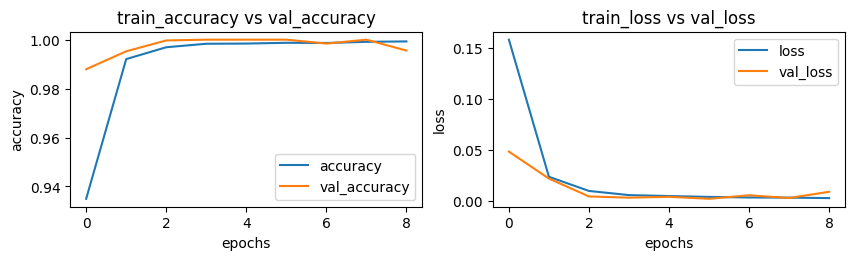

70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


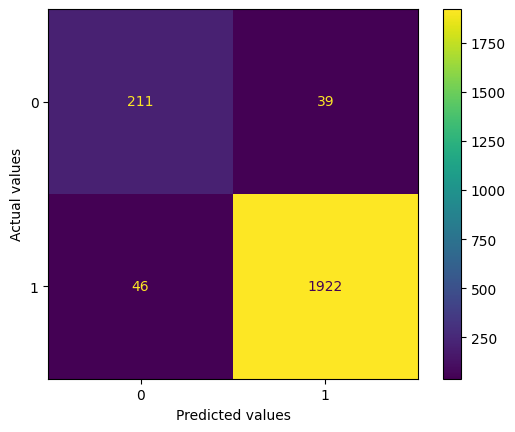

,name,acc,f1,prec,rec,loss
0,tf_model,0.961677,0.961677,0.961677,0.961677,0.291114


<Figure size 640x480 with 0 Axes>

In [50]:
train_evaluation_with_tf(X_train, y_train,X_test,y_test,"en")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.7726 - loss: 0.4867 - val_accuracy: 0.8228 - val_loss: 0.4006
Epoch 2/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9145 - loss: 0.2194 - val_accuracy: 0.8125 - val_loss: 0.4794
Epoch 3/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9711 - loss: 0.0916 - val_accuracy: 0.8099 - val_loss: 0.6031
Epoch 4/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9875 - loss: 0.0422 - val_accuracy: 0.7924 - val_loss: 0.8423
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8234 - loss: 0.3787


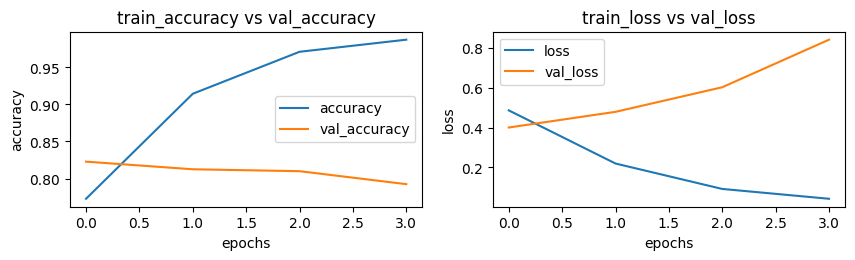

76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


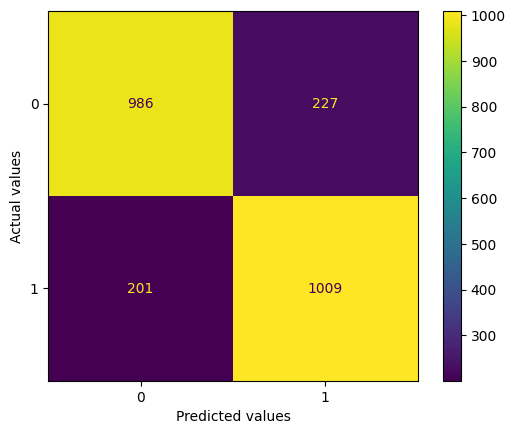

,name,acc,f1,prec,rec,loss
0,tf_model,0.823359,0.823359,0.823359,0.823359,0.378701


<Figure size 640x480 with 0 Axes>

In [55]:
train_evaluation_with_tf(X_train, y_train,X_test,y_test,"ar")

In [51]:
import torch
import torch.nn as nn
import torch.optim as opti

class ANN(nn.Module):
    def __init__(self, input_size):
        super(ANN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [52]:
def train_evaluation_with_torch(X_train, y_train, X_test, y_test,language):

    summary = []
    # Split validation (like validation_split=0.2)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1)

    # Convert to tensors
    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
    X_val = torch.tensor(X_val, dtype=torch.float32)
    y_val = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

    model = ANN(input_size=X_train.shape[1])

    criterion = nn.BCELoss()
    optimizer = opti.Adam(model.parameters(), lr=0.001)

    # Early stopping params
    patience = 5
    best_val_loss = float("inf")
    patience_counter = 0
    best_model_state = None

    history = {
        "loss": [],
        "val_loss": [],
        "accuracy": [],
        "val_accuracy": []
    }

    # Training loop
    epochs = 50
    for epoch in range(epochs):
        model.train()

        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Train accuracy
        preds = (outputs > 0.5).float()
        acc = (preds == y_train).float().mean()

        # Validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, y_val)

            val_preds = (val_outputs > 0.5).float()
            val_acc = (val_preds == y_val).float().mean()

        # Save history
        history["loss"].append(loss.item())
        history["val_loss"].append(val_loss.item())
        history["accuracy"].append(acc.item())
        history["val_accuracy"].append(val_acc.item())

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Loss: {loss.item():.4f}, Acc: {acc.item():.4f} | "
              f"Val Loss: {val_loss.item():.4f}, Val Acc: {val_acc.item():.4f}")

        # Early stopping
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_model_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered")
            break

    # Restore best weights
    if best_model_state:
        model.load_state_dict(best_model_state)

    # Evaluation
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_tensor)
        test_loss = criterion(test_outputs,torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1))

        y_pred_proba = test_outputs.numpy()
        y_pred = (y_pred_proba > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="micro")
    prec = precision_score(y_test, y_pred, average="micro")
    rec = recall_score(y_test, y_pred, average="micro")

    # Save outputs
    os.makedirs("torch_model", exist_ok=True)

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.xlabel('Predicted values')
    plt.ylabel('Actual values')
    plt.show()
    plt.savefig(f"torch_model/confusion_matrix_{language}.png")

    summary.append({"name": "torch_model","acc": acc,"f1": f1,"prec": prec,"rec": rec,"loss": test_loss.item()})
    summary = pd.DataFrame(summary)
    summary.to_csv("torch_model/summary.csv", index=False)
    display(summary)

    # Save model
    torch.save(model.state_dict(), f"torch_model/model_{language}.pth")

    # Plot history
    plot_accuracy_loss_torch(history)

Epoch 1/50 | Loss: 0.6949, Acc: 0.4989 | Val Loss: 0.6874, Val Acc: 0.5114
Epoch 2/50 | Loss: 0.6882, Acc: 0.5019 | Val Loss: 0.6799, Val Acc: 0.5381
Epoch 3/50 | Loss: 0.6804, Acc: 0.5345 | Val Loss: 0.6703, Val Acc: 0.6067
Epoch 4/50 | Loss: 0.6707, Acc: 0.5963 | Val Loss: 0.6592, Val Acc: 0.6696
Epoch 5/50 | Loss: 0.6591, Acc: 0.6642 | Val Loss: 0.6465, Val Acc: 0.7281
Epoch 6/50 | Loss: 0.6458, Acc: 0.7253 | Val Loss: 0.6326, Val Acc: 0.7948
Epoch 7/50 | Loss: 0.6318, Acc: 0.7870 | Val Loss: 0.6174, Val Acc: 0.8494
Epoch 8/50 | Loss: 0.6157, Acc: 0.8434 | Val Loss: 0.6009, Val Acc: 0.8850
Epoch 9/50 | Loss: 0.5991, Acc: 0.8882 | Val Loss: 0.5833, Val Acc: 0.9282
Epoch 10/50 | Loss: 0.5809, Acc: 0.9208 | Val Loss: 0.5645, Val Acc: 0.9460
Epoch 11/50 | Loss: 0.5614, Acc: 0.9430 | Val Loss: 0.5447, Val Acc: 0.9549
Epoch 12/50 | Loss: 0.5411, Acc: 0.9579 | Val Loss: 0.5241, Val Acc: 0.9593
Epoch 13/50 | Loss: 0.5204, Acc: 0.9668 | Val Loss: 0.5027, Val Acc: 0.9587
Epoch 14/50 | Loss: 0

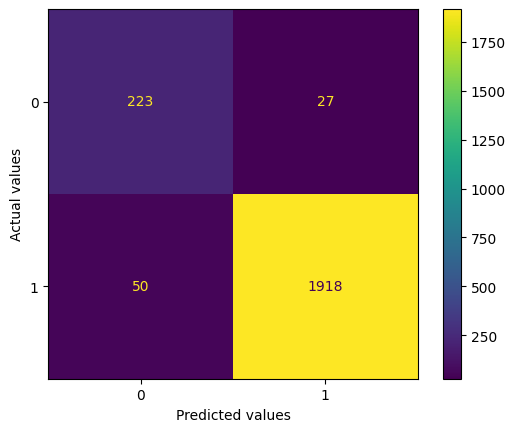

,name,acc,f1,prec,rec,loss
0,torch_model,0.965284,0.965284,0.965284,0.965284,0.177651


<Figure size 640x480 with 0 Axes>

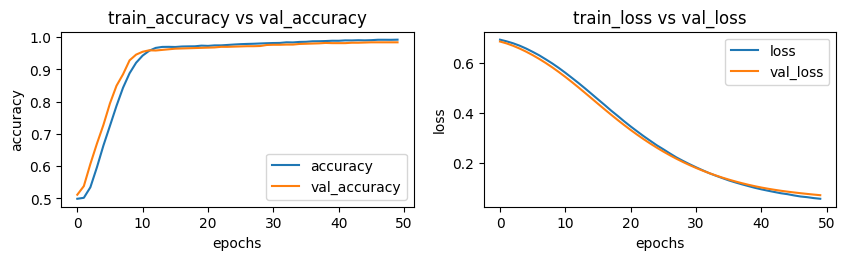

In [53]:
model = train_evaluation_with_torch(X_train, y_train,X_test, y_test,"english")

Epoch 1/50 | Loss: 0.6945, Acc: 0.4983 | Val Loss: 0.6908, Val Acc: 0.5149
Epoch 2/50 | Loss: 0.6889, Acc: 0.5251 | Val Loss: 0.6877, Val Acc: 0.5633
Epoch 3/50 | Loss: 0.6819, Acc: 0.5901 | Val Loss: 0.6832, Val Acc: 0.6004
Epoch 4/50 | Loss: 0.6731, Acc: 0.6576 | Val Loss: 0.6765, Val Acc: 0.6550
Epoch 5/50 | Loss: 0.6618, Acc: 0.7261 | Val Loss: 0.6676, Val Acc: 0.7281
Epoch 6/50 | Loss: 0.6490, Acc: 0.7732 | Val Loss: 0.6577, Val Acc: 0.7611
Epoch 7/50 | Loss: 0.6349, Acc: 0.8084 | Val Loss: 0.6474, Val Acc: 0.7714
Epoch 8/50 | Loss: 0.6199, Acc: 0.8289 | Val Loss: 0.6369, Val Acc: 0.7703
Epoch 9/50 | Loss: 0.6031, Acc: 0.8453 | Val Loss: 0.6258, Val Acc: 0.7734
Epoch 10/50 | Loss: 0.5862, Acc: 0.8554 | Val Loss: 0.6132, Val Acc: 0.7755
Epoch 11/50 | Loss: 0.5680, Acc: 0.8629 | Val Loss: 0.5997, Val Acc: 0.7827
Epoch 12/50 | Loss: 0.5482, Acc: 0.8700 | Val Loss: 0.5861, Val Acc: 0.7889
Epoch 13/50 | Loss: 0.5286, Acc: 0.8780 | Val Loss: 0.5730, Val Acc: 0.7909
Epoch 14/50 | Loss: 0

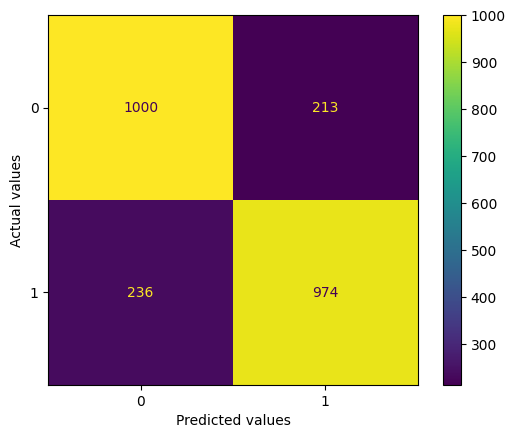

,name,acc,f1,prec,rec,loss
0,torch_model,0.814693,0.814693,0.814693,0.814693,0.485518


<Figure size 640x480 with 0 Axes>

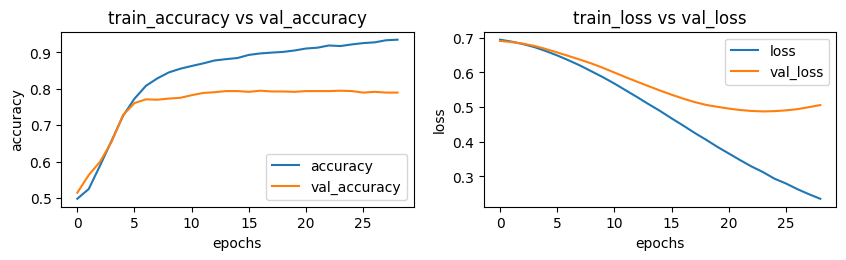

In [56]:
model = train_evaluation_with_torch(X_train, y_train,X_test, y_test,"arabic")

In [60]:
def predict_arabic(text):
  if isinstance(text, str):
    text = pd.Series([text])
  Numbers = text.str.count(r"\d")
  Special = text.str.count(r"[!@#$%^&*()]")
  processed_text_features = text.apply(process_review_text_ar)
  review = pd.DataFrame({"Numbers": Numbers, "Special": Special,"r_ar": processed_text_features[0],"RLength": processed_text_features[1], "SentenceLength": processed_text_features[2]})
  review = preprocessor.transform(review)
  model = tf.keras.models.load_model("tf_model/tf_model.keras")
  prediction = model.predict(review)
  prediction = (prediction > 0.5).astype(int)
  return prediction

In [69]:
def predict_english(text):
  if isinstance(text, str):
    text = pd.Series([text])
  Numbers = text.str.count(r"\d")
  Special = text.str.count(r"[!@#$%^&*()]")
  processed_text_features = text.apply(process_review_text_en)
  review = pd.DataFrame({"Numbers": Numbers, "Special": Special,"r_en": processed_text_features[0],"RLength": processed_text_features[1], "SentenceLength": processed_text_features[2]})
  preprocessor = joblib.load("preprocessor_r_en.pkl")
  review = preprocessor.transform(review).toarray()
  review_tensor = torch.tensor(review, dtype=torch.float32)

    # Load model
  input_size = review.shape[1]
  model = ANN(input_size)
  model.load_state_dict(torch.load("/content/torch_model/model_english.pth"))
  model.eval()

    # Prediction
  with torch.no_grad():
    outputs = model(review_tensor)
    prediction = (outputs > 0.5).int().numpy()

  return prediction

In [71]:
predict_english("hate")

array([[0]], dtype=int32)